In [1]:
from pathlib import Path
from typing import Callable

import lightning as L
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision.io import ImageReadMode, read_image


class FungiTasticDataset(Dataset):
  """Dataset backed by compact per-split NPZ mask files.

  The image files still come from the regular 300p FungiTastic Mini download.
  The masks are precomputed semantic masks produced by
  scripts/compact_segmentation_dataset.py.
  """

  LABEL_TO_ID = {
    "cap": 1,
    "stem": 2,
    "gills": 3,
    "pores": 4,
    "ring": 5,
    "ridges": 6,
    "teeth": 7,
    "unknown underside": 8
  }

  DEFAULT_COMPACT_DIR = "FungiTastic-Mini-Segmentation-300p-NPZ"

  def __init__(
      self,
      data_root: str | Path,
      split: str,
      transform: Callable | None = None,
      compact_root: str | Path | None = None,
  ):
    self.data_root = Path(data_root)
    self.split = split
    self.transform = transform

    if compact_root is None:
      compact_root = self.data_root / self.DEFAULT_COMPACT_DIR
    self.compact_root = Path(compact_root)

    split_path = self.compact_root / f"{split}.npz"
    if not split_path.is_file():
      raise FileNotFoundError(
        f"Compact split file not found: {split_path}. "
        "Run `uv run python scripts/compact_segmentation_dataset.py` first."
      )

    with np.load(split_path, allow_pickle=False) as data:
      self.filenames = data["filenames"].astype(str).tolist()
      image_rel_paths = data["image_rel_paths"].astype(str).tolist()
      self.image_paths = [
        str(self.data_root / image_rel_path)
        for image_rel_path in image_rel_paths
      ]
      self.image_widths = data["image_widths"].astype(np.int32)
      self.image_heights = data["image_heights"].astype(np.int32)
      self.label_names = data["label_names"].astype(str).tolist()
      self.target_size = int(data["target_size"])

      # NPZ is compressed, so this necessarily decompresses the mask array.
      # Keeping it in RAM makes training reads cheap and avoids per-sample
      # decompression. For train this is about 1.16 GiB at 300x300.
      self.masks = np.asarray(data["masks"], dtype=np.uint8)

    if len(self.image_paths) != len(self.masks):
      raise ValueError(
        f"Image/mask count mismatch for {split}: "
        f"{len(self.image_paths)} images vs {len(self.masks)} masks"
      )

  def __len__(self) -> int:
    return len(self.filenames)

  def __getitem__(self, idx: int):
    image = read_image(self.image_paths[idx], mode=ImageReadMode.RGB)
    image = self._pad_crop_image_300(image, self.target_size)
    image = image.float() / 255.0

    mask = torch.from_numpy(self.masks[idx]).long()

    if self.transform is not None:
      image, mask = self.transform(image, mask)

    return image, mask

  @staticmethod
  def _pad_crop_image_300(image: torch.Tensor, target: int = 300) -> torch.Tensor:
    _, height, width = image.shape

    pad_h = max(0, target - height)
    pad_w = max(0, target - width)

    top = pad_h // 2
    bottom = pad_h - top
    left = pad_w // 2
    right = pad_w - left

    image = torch.nn.functional.pad(
      image,
      (left, right, top, bottom),
      value=0
    )

    _, height, width = image.shape

    top = max(0, (height - target) // 2)
    left = max(0, (width - target) // 2)

    return image[:, top:top + target, left:left + target]

In [2]:
DATA_ROOT = Path('../data/FungiTastic')
dataset = FungiTasticDataset(DATA_ROOT, 'train')

# print(dataset[0])
print(len(dataset))

13803


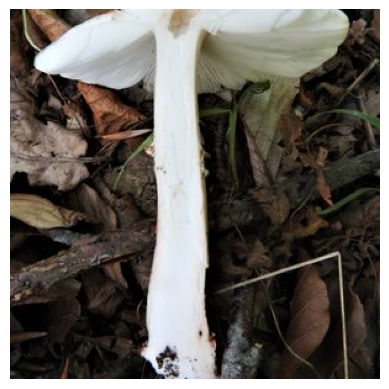

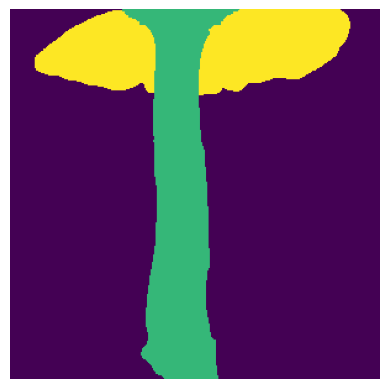

13803


In [3]:
import matplotlib.pyplot as plt

img, mask = dataset[2137]
img = img.permute(1, 2, 0)

plt.imshow(img)
plt.axis('off')
plt.show()

plt.imshow(mask)
plt.axis('off')
plt.show()

print(len(dataset))